In [2]:
import pandas as pd 

train = pd.read_csv('playground-series-s6e4/train.csv')

In [3]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
test = pd.read_csv('playground-series-s6e4/test.csv')
test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


DATASET SHAPE
(630000, 21)

Columns:
Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

Target Distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Missing Values:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type       

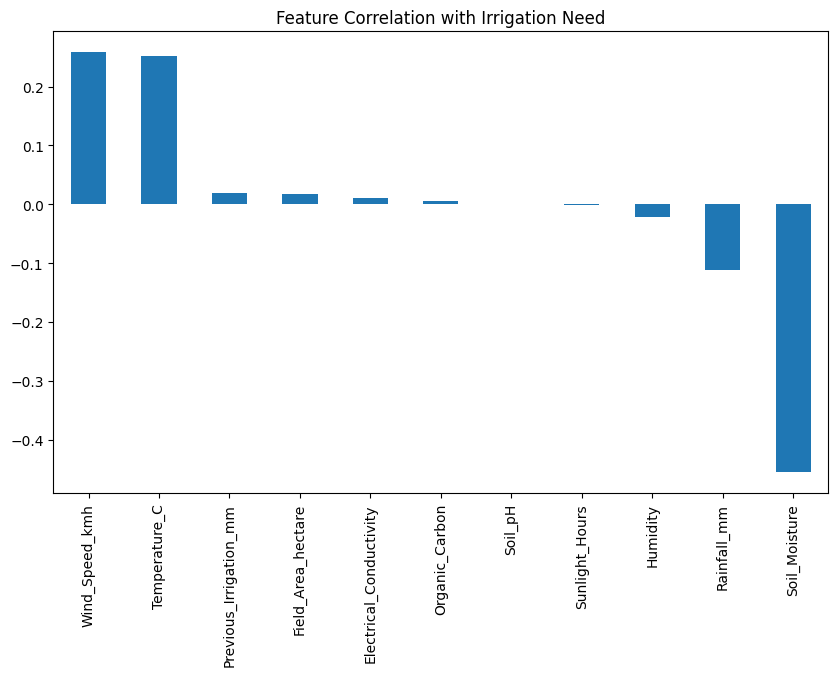

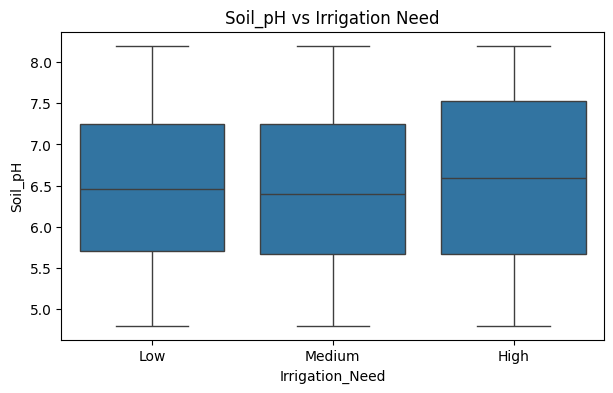

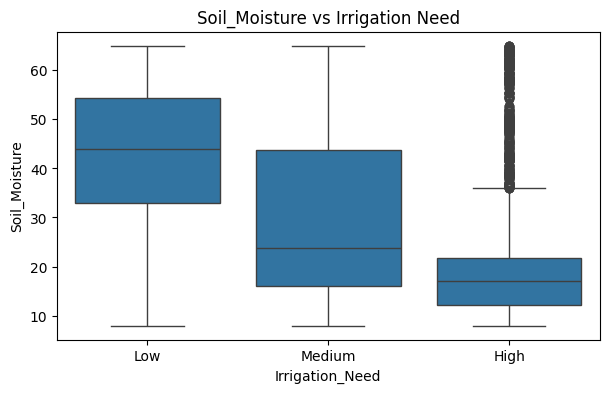

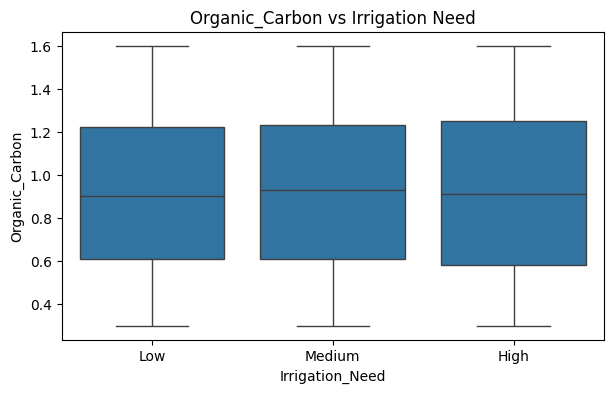

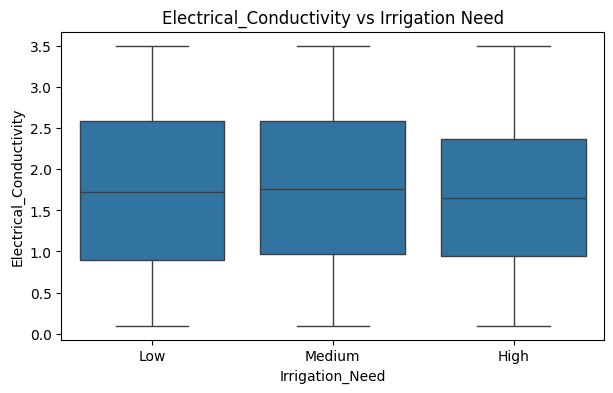

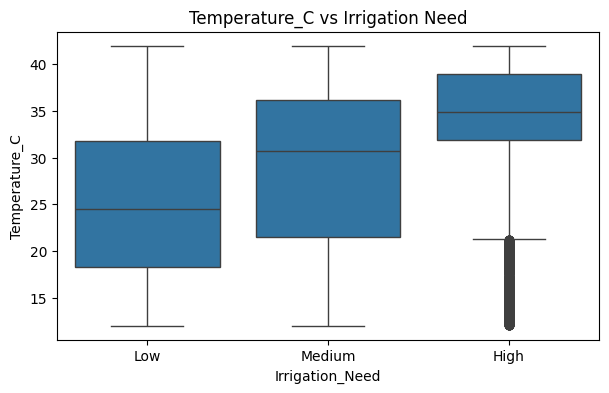

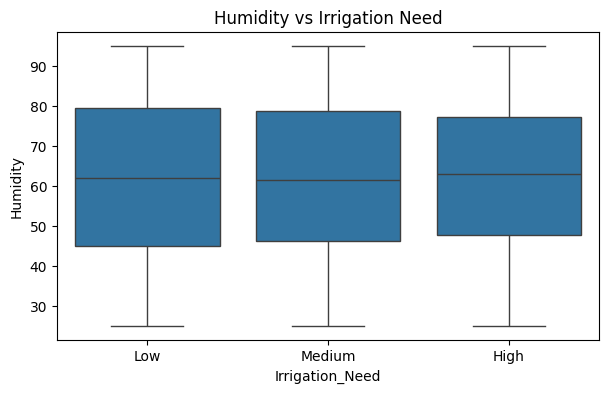

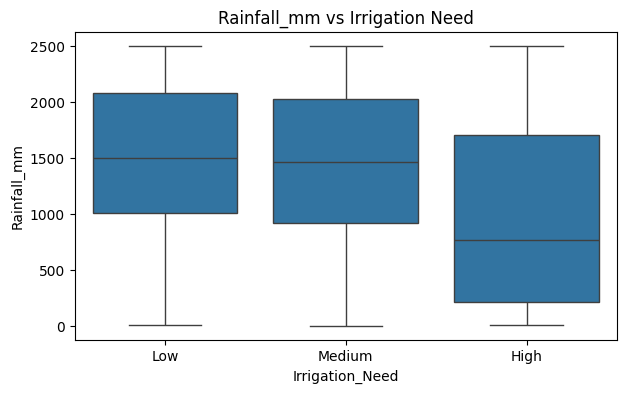

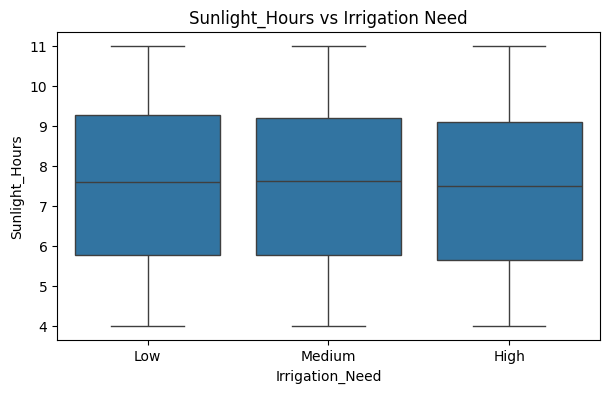

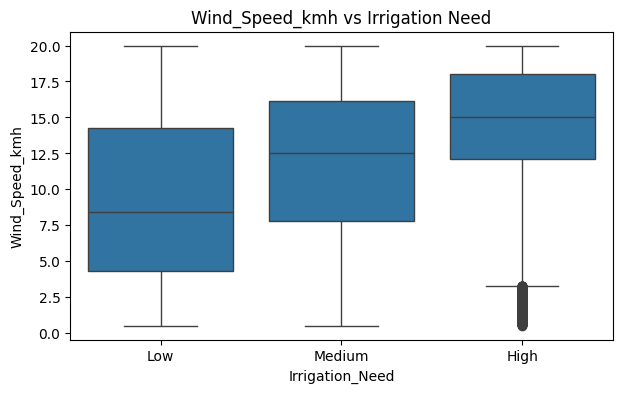

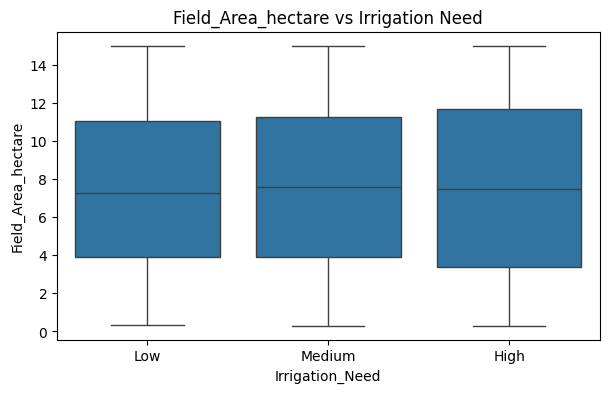

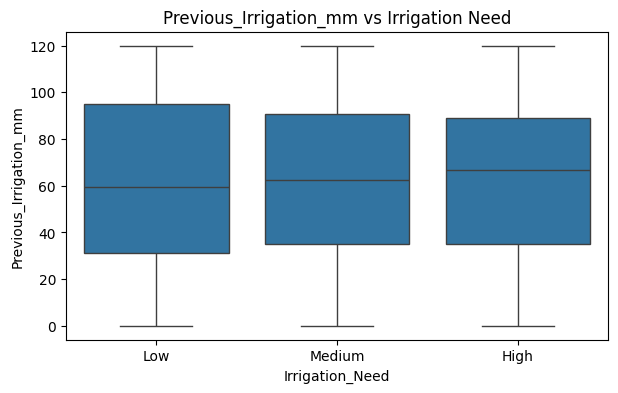

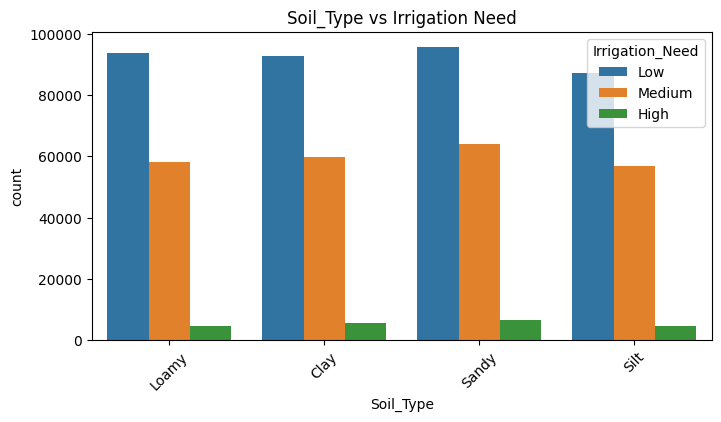

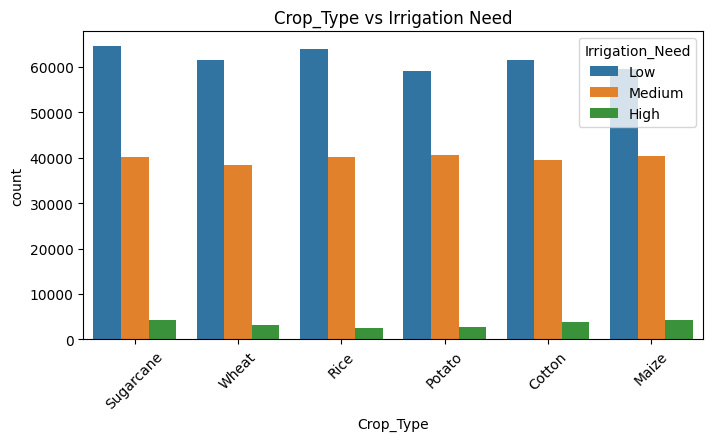

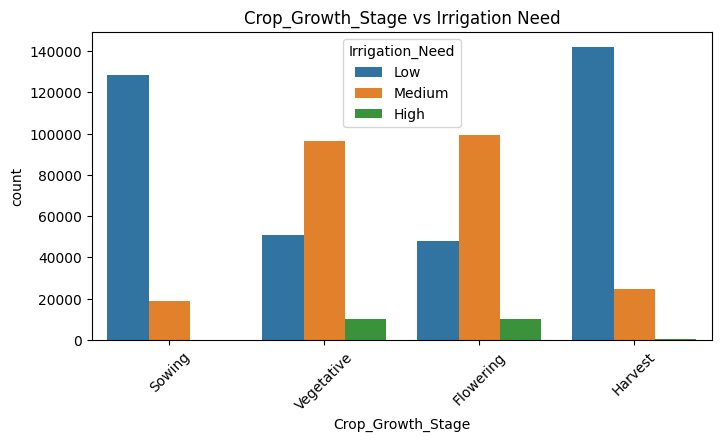

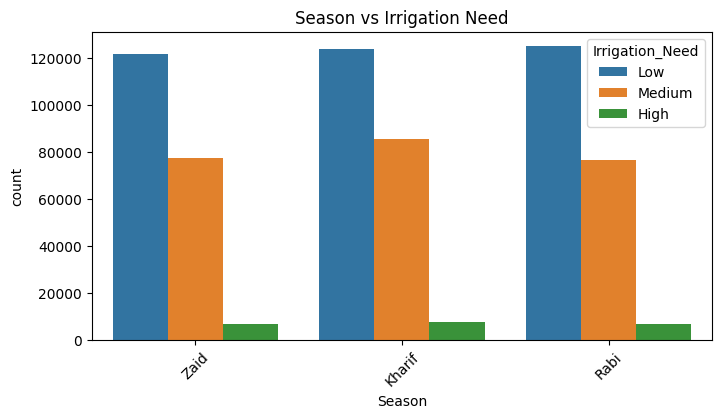

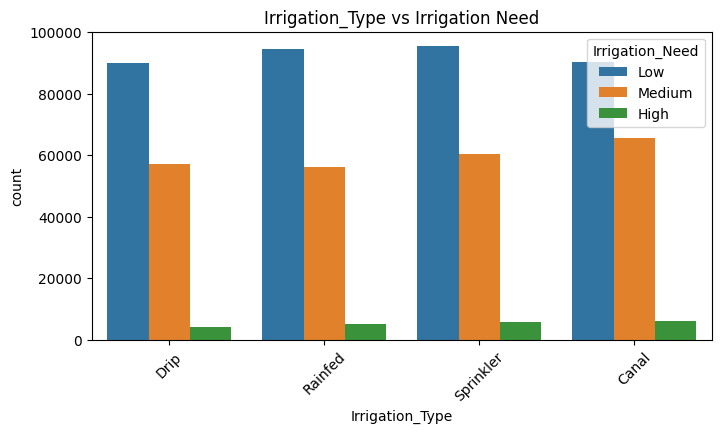

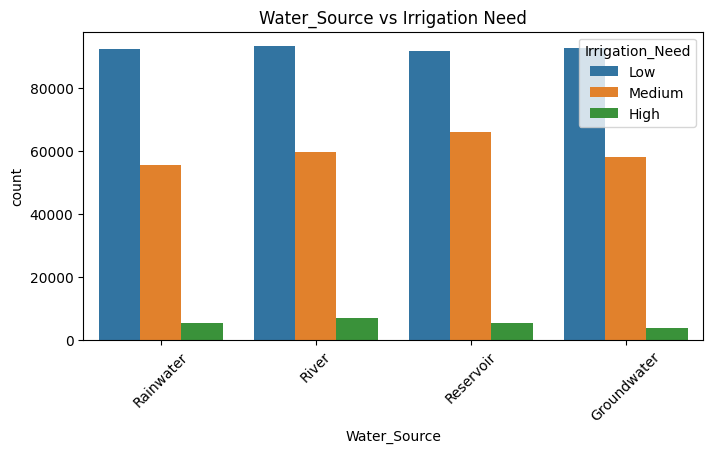

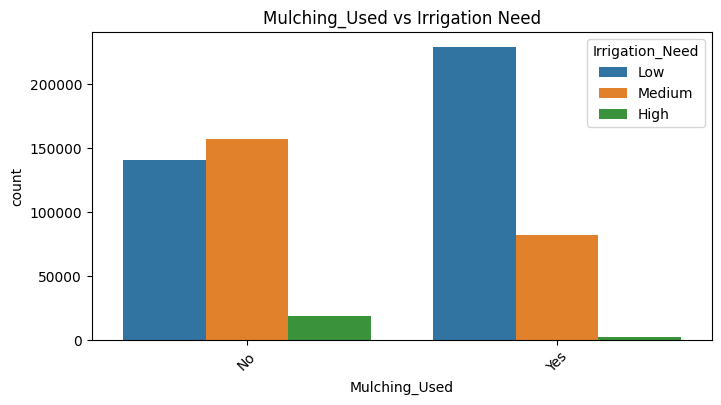

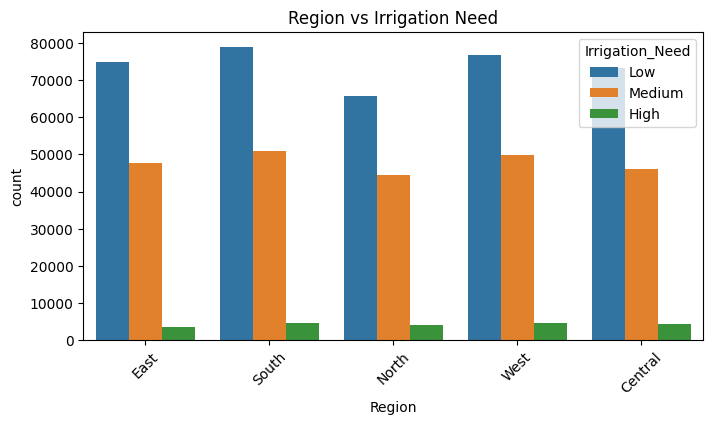

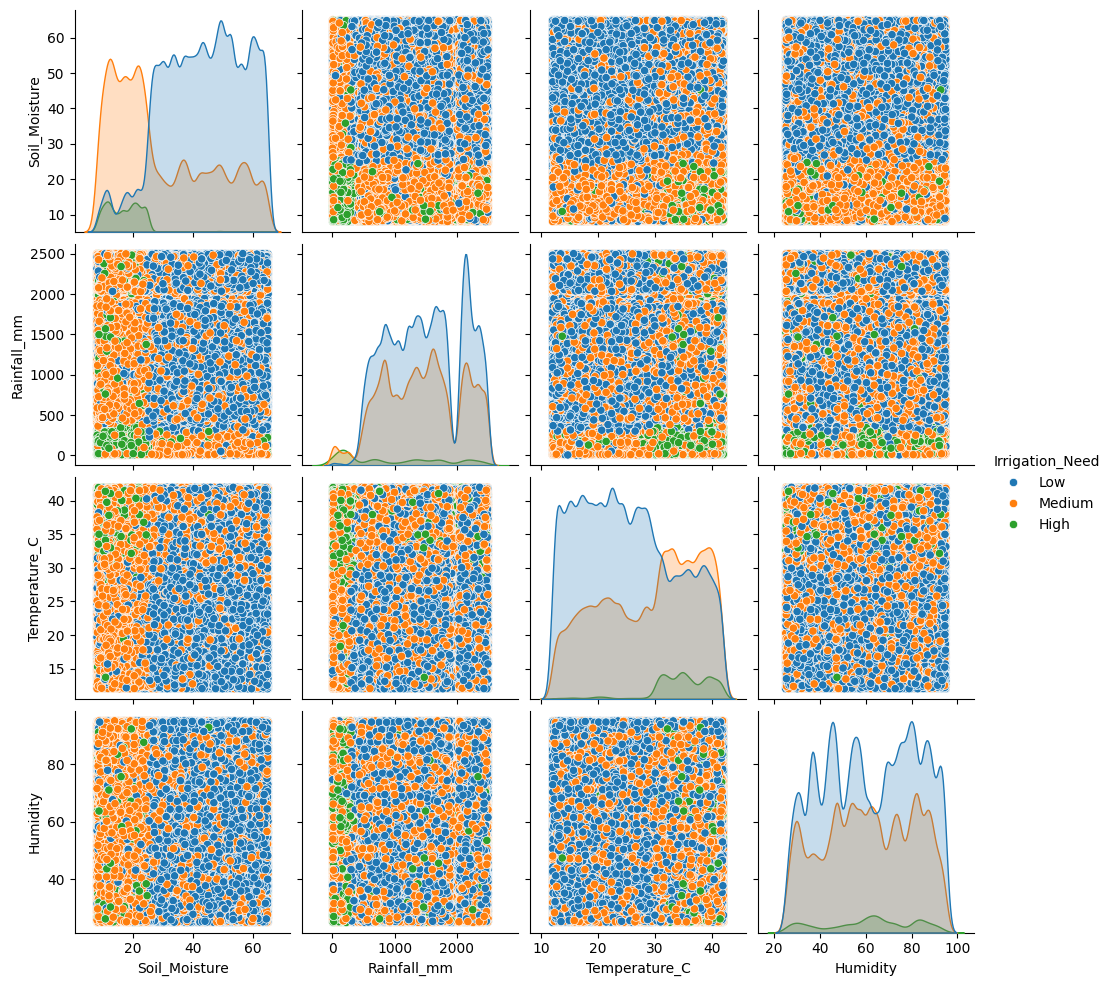

Done!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load train data
df = train.copy()

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nTarget Distribution:")
print(df['Irrigation_Need'].value_counts())

# -----------------------------
# Missing Values
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Numerical Columns
# -----------------------------
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('id')

# -----------------------------
# Target Encoding
# -----------------------------
target_map = {'Low':0,'Medium':1,'High':2}
df['Target_Num'] = df['Irrigation_Need'].map(target_map)

# -----------------------------
# Correlation With Target
# -----------------------------
corr = df[num_cols + ['Target_Num']].corr()['Target_Num'].sort_values(ascending=False)

print("\nCorrelation with Irrigation Need:")
print(corr)

plt.figure(figsize=(10,6))
corr.drop('Target_Num').plot(kind='bar')
plt.title("Feature Correlation with Irrigation Need")
plt.show()

# -----------------------------
# Boxplots
# -----------------------------
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Irrigation_Need', y=col)
    plt.title(f"{col} vs Irrigation Need")
    plt.show()

# -----------------------------
# Categorical Analysis
# -----------------------------
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Irrigation_Need')

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='Irrigation_Need')
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Irrigation Need")
    plt.show()

# -----------------------------
# Pair Relationships
# -----------------------------
important = ['Soil_Moisture','Rainfall_mm','Temperature_C','Humidity']
sns.pairplot(df[important + ['Irrigation_Need']], hue='Irrigation_Need')
plt.show()
print("Done!")

LIGHTWEIGHT PRO FORMULA DISCOVERY

Balanced Accuracy: 0.754053

Top 15 Important Features:
                    Feature  Importance
12        Crop_Growth_Stage    0.281696
3             Soil_Moisture    0.250514
17            Mulching_Used    0.102428
10           Wind_Speed_kmh    0.087753
6             Temperature_C    0.080548
8               Rainfall_mm    0.031036
18   Previous_Irrigation_mm    0.015241
7                  Humidity    0.013506
16       Field_Area_hectare    0.012537
2                   Soil_pH    0.012492
5   Electrical_Conductivity    0.012405
4            Organic_Carbon    0.012258
9            Sunlight_Hours    0.012145
0                        id    0.011962
11                Crop_Type    0.011214


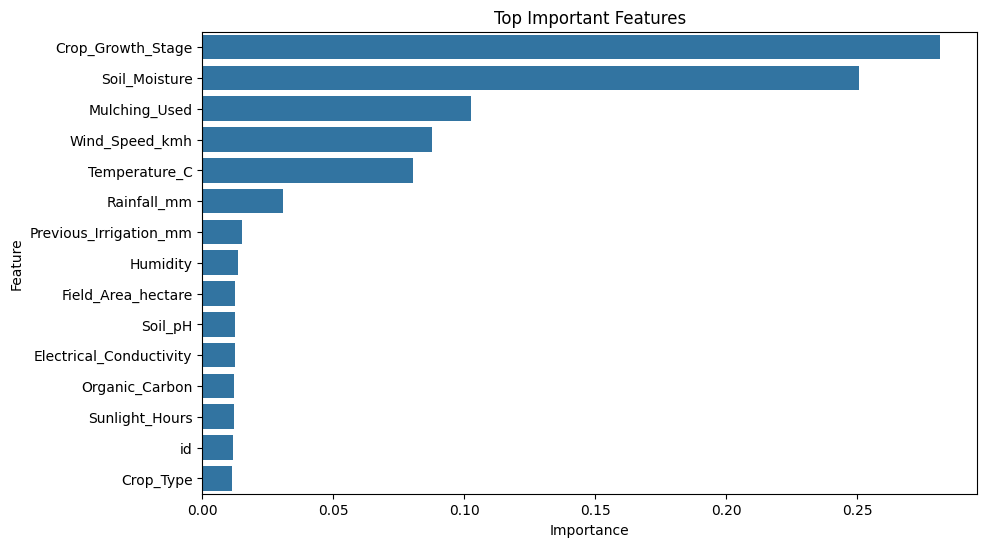


Human Readable Rules:

|--- Soil_Moisture <= 24.99
|   |--- Rainfall_mm <= 347.93
|   |   |--- Temperature_C <= 30.05
|   |   |   |--- Rainfall_mm <= 121.40
|   |   |   |   |--- class: 1
|   |   |   |--- Rainfall_mm >  121.40
|   |   |   |   |--- class: 2
|   |   |--- Temperature_C >  30.05
|   |   |   |--- Wind_Speed_kmh <= 10.37
|   |   |   |   |--- class: 2
|   |   |   |--- Wind_Speed_kmh >  10.37
|   |   |   |   |--- class: 2
|   |--- Rainfall_mm >  347.93
|   |   |--- Crop_Growth_Stage <= 2.50
|   |   |   |--- Crop_Growth_Stage <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Crop_Growth_Stage >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Crop_Growth_Stage >  2.50
|   |   |   |--- Temperature_C <= 29.93
|   |   |   |   |--- class: 1
|   |   |   |--- Temperature_C >  29.93
|   |   |   |   |--- class: 1
|--- Soil_Moisture >  24.99
|   |--- Crop_Growth_Stage <= 0.50
|   |   |--- Wind_Speed_kmh <= 9.99
|   |   |   |--- Temperature_C <= 30.02
|   |   |   |   |--- class: 0
|

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

print("="*60)
print("LIGHTWEIGHT PRO FORMULA DISCOVERY")
print("="*60)

df = train.copy()

# ----------------------------
# Reduce memory
# ----------------------------
for col in df.select_dtypes(include='float64').columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include='int64').columns:
    df[col] = df[col].astype('int32')

# ----------------------------
# Sample rows if huge dataset
# ----------------------------
if len(df) > 100000:
    df = df.sample(60000, random_state=42)

# ----------------------------
# Target
# ----------------------------
target_map = {'Low':0,'Medium':1,'High':2}
df['Target_Num'] = df['Irrigation_Need'].map(target_map)

# ----------------------------
# Fill missing
# ----------------------------
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ----------------------------
# Encode categoricals
# ----------------------------
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Irrigation_Need')

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# ----------------------------
# Features
# ----------------------------
X = df.drop(columns=['Irrigation_Need','Target_Num'])
y = df['Target_Num']

feature_cols = X.columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# Extra Trees (Fast)
# ----------------------------
model = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_val)
score = balanced_accuracy_score(y_val, pred)

print(f"\nBalanced Accuracy: {score:.6f}")

# ----------------------------
# Feature Importance
# ----------------------------
imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Important Features:")
print(imp.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=imp.head(15), y='Feature', x='Importance')
plt.title("Top Important Features")
plt.show()

# ----------------------------
# Formula Rules
# ----------------------------
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    random_state=42
)

tree.fit(X_train, y_train)

print("\nHuman Readable Rules:\n")
print(export_text(tree, feature_names=feature_cols))

print("="*60)
print("DONE")
print("="*60)

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# LOAD
# =========================
df = train.copy()

# Target encoding
target_map = {'Low':0, 'Medium':1, 'High':2}
df['target'] = df['Irrigation_Need'].map(target_map)

# Keep copy
target = df['target']

# Drop target/id
X = df.drop(columns=['Irrigation_Need', 'target'], errors='ignore')

# =========================
# Encode categorical columns
# =========================
encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# =========================
# Scale
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# Train linear model
# =========================
model = LogisticRegression(
    max_iter=3000,
    solver='lbfgs'
)

model.fit(X_scaled, target)

# =========================
# Print formula
# =========================
cols = X.columns.tolist()

print("="*70)
print("MATHEMATICAL FORMULA")
print("="*70)

for cls in range(3):
    print(f"\nCLASS {cls} ({['Low','Medium','High'][cls]})")

    formula = f"Score_{cls} = {model.intercept_[cls]:.4f}"

    for i, c in enumerate(cols):
        coef = model.coef_[cls][i]
        formula += f" + ({coef:.4f} * {c})"

    print(formula)

print("\nFinal Prediction = argmax(Score_0, Score_1, Score_2)")
print("="*70)

MATHEMATICAL FORMULA

CLASS 0 (Low)
Score_0 = 2.4834 + (0.0024 * id) + (0.0246 * Soil_Type) + (-0.0185 * Soil_pH) + (1.4451 * Soil_Moisture) + (0.0218 * Organic_Carbon) + (0.0062 * Electrical_Conductivity) + (-0.8779 * Temperature_C) + (0.0299 * Humidity) + (0.3446 * Rainfall_mm) + (-0.0051 * Sunlight_Hours) + (-0.7965 * Wind_Speed_kmh) + (0.0129 * Crop_Type) + (-0.0033 * Crop_Growth_Stage) + (0.0060 * Season) + (-0.0091 * Irrigation_Type) + (-0.0753 * Water_Source) + (-0.0181 * Field_Area_hectare) + (0.9016 * Mulching_Used) + (-0.0006 * Previous_Irrigation_mm) + (-0.0248 * Region)

CLASS 1 (Medium)
Score_1 = 1.9135 + (0.0014 * id) + (0.0121 * Soil_Type) + (-0.0464 * Soil_pH) + (0.2333 * Soil_Moisture) + (0.0139 * Organic_Carbon) + (0.0420 * Electrical_Conductivity) + (-0.2141 * Temperature_C) + (-0.0089 * Humidity) + (0.2146 * Rainfall_mm) + (0.0076 * Sunlight_Hours) + (-0.0888 * Wind_Speed_kmh) + (0.0077 * Crop_Type) + (-0.0264 * Crop_Growth_Stage) + (-0.0133 * Season) + (-0.0288 * I

In [8]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
train = pd.read_csv('/home/prinshu/Desktop/Machine_learning/Irrigation_predictor/playground-series-s6e4/train.csv')
test = pd.read_csv('/home/prinshu/Desktop/Machine_learning/Irrigation_predictor/playground-series-s6e4/test.csv')
sample = pd.read_csv('/home/prinshu/Desktop/Machine_learning/Irrigation_predictor/playground-series-s6e4/sample_submission.csv')
# ============================================================
# 🔥 LATEST GPU WINNING NOTEBOOK (2026 COMPATIBLE)
# CatBoost GPU + XGBoost CUDA + Formula Features
# For 630K Rows Dataset
# ============================================================

# ============================================================
# INSTALL (Run once if needed)
# ============================================================
# !pip install -q catboost xgboost

# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from sklearn.ensemble import VotingClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# ============================================================
# LOAD DATA
# ============================================================

print("="*60)
print("DATA LOADED")
print("="*60)
print("Train:", train.shape)
print("Test :", test.shape)

# ============================================================
# TARGET
# ============================================================
target_map = {'Low':0, 'Medium':1, 'High':2}
reverse_map = {0:'Low', 1:'Medium', 2:'High'}

y = train['Irrigation_Need'].map(target_map)

# ============================================================
# DROP TARGET
# ============================================================
train_x = train.drop(columns=['Irrigation_Need'])

# ============================================================
# COMBINE FOR SAME PREPROCESSING
# ============================================================
full = pd.concat([train_x, test], axis=0).reset_index(drop=True)

# ============================================================
# COLUMN TYPES
# ============================================================
cat_cols = full.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in full.columns if c not in cat_cols]

# ============================================================
# HANDLE MISSING
# ============================================================
for col in num_cols:
    full[col] = full[col].fillna(full[col].median())

for col in cat_cols:
    full[col] = full[col].fillna("Missing")

# ============================================================
# LABEL ENCODING
# ============================================================
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    full[col] = le.fit_transform(full[col].astype(str))
    encoders[col] = le

# ============================================================
# FEATURE ENGINEERING
# ============================================================
full['Moisture_Rainfall_Ratio'] = full['Soil_Moisture'] / (full['Rainfall_mm'] + 1)
full['Temp_Humidity_Ratio'] = full['Temperature_C'] / (full['Humidity'] + 1)

full['Moisture_Temp'] = full['Soil_Moisture'] * full['Temperature_C']
full['Rain_Wind'] = full['Rainfall_mm'] * full['Wind_Speed_kmh']

full['Soil_Moisture_sq'] = full['Soil_Moisture'] ** 2
full['Temperature_sq'] = full['Temperature_C'] ** 2

full['Low_Moisture'] = (full['Soil_Moisture'] < 25).astype(int)
full['High_Temp'] = (full['Temperature_C'] > 30).astype(int)
full['Low_Rain'] = (full['Rainfall_mm'] < 300).astype(int)

# ============================================================
# SPLIT BACK
# ============================================================
X_train = full.iloc[:len(train)].copy()
X_test = full.iloc[len(train):].copy()

# ============================================================
# FORMULA FEATURES
# ============================================================
def add_formula(df):
    X = df.values

    score_low = (
        2.4834 + 0.0024*X[:,0] + 1.4451*X[:,3]
        -0.8779*X[:,6] + 0.3446*X[:,8]
        -0.7965*X[:,10] + 0.9016*X[:,17]
    )

    score_med = (
        1.9135 + 0.0014*X[:,0] + 0.2333*X[:,3]
        -0.2141*X[:,6] + 0.2146*X[:,8]
        -0.0888*X[:,10]
    )

    score_high = (
        -4.3969 -1.6784*X[:,3]
        +1.0920*X[:,6]
        -0.5592*X[:,8]
        +0.8853*X[:,10]
        -0.9893*X[:,17]
    )

    df['score_low'] = score_low
    df['score_med'] = score_med
    df['score_high'] = score_high

    return df

X_train = add_formula(X_train)
X_test = add_formula(X_test)

# ============================================================
# CATBOOST GPU
# ============================================================
cat_model = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    task_type='GPU',
    devices='0',
    verbose=100,
    random_state=42
)

# ============================================================
# XGBOOST GPU (LATEST VERSION)
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    random_state=42
)

# ============================================================
# ENSEMBLE
# ============================================================
ensemble = VotingClassifier(
    estimators=[
        ('cat', cat_model),
        ('xgb', xgb_model)
    ],
    voting='soft',
    n_jobs=1
)

# ============================================================
# TRAIN
# ============================================================
print("="*60)
print("🔥 TRAINING GPU MODELS")
print("="*60)

ensemble.fit(X_train, y)

# ============================================================
# TRAIN SCORE
# ============================================================
train_pred = ensemble.predict(X_train)
train_ba = balanced_accuracy_score(y, train_pred)

print("="*60)
print("TRAIN BALANCED ACCURACY:", round(train_ba,6))
print("="*60)

# ============================================================
# TEST PREDICT
# ============================================================
pred = ensemble.predict(X_test)

sample['Irrigation_Need'] = [reverse_map[int(i)] for i in pred]

# ============================================================
# SAVE
# ============================================================
sample.to_csv('/home/prinshu/Desktop/Machine_learning/Irrigation_predictor/playground-series-s6e4/final_submission_gpu_latest.csv', index=False)

print("🔥 SUBMISSION SAVED")
print("/content/final_submission_gpu_latest.csv")
print(sample.head())

DATA LOADED
Train: (630000, 21)
Test : (270000, 20)
🔥 TRAINING GPU MODELS
0:	learn: 1.0054707	total: 37ms	remaining: 11.1s
100:	learn: 0.0651144	total: 2.84s	remaining: 5.59s
200:	learn: 0.0605098	total: 5.21s	remaining: 2.57s
299:	learn: 0.0586634	total: 7.56s	remaining: 0us
TRAIN BALANCED ACCURACY: 0.966271
🔥 SUBMISSION SAVED
/content/final_submission_gpu_latest.csv
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
